This cell loads the dataset from a URL into a pandas DataFrame named `df`.

In [1]:
import pandas as pd


url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv"

df = pd.read_csv(url)

This cell imports necessary libraries for data manipulation, numerical operations, plotting, and statistical visualizations.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

This cell imports necessary modules from `sklearn` for model training: `train_test_split` for splitting data, `StandardScaler` for feature scaling, `LabelEncoder` for encoding target labels, and `LogisticRegression` for the classification model.

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression

This cell imports evaluation metrics (`accuracy_score`, `classification_report`, `confusion_matrix`) from `sklearn.metrics` and visualization libraries (`seaborn`, `matplotlib.pyplot`) for model assessment.

In [43]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

This cell imports the `KNeighborsClassifier` from `sklearn.neighbors` to implement the K-Nearest Neighbors algorithm.

In [46]:
from sklearn.neighbors import KNeighborsClassifier

This cell displays a concise summary of the DataFrame, including data types and non-null values for each column.

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


### Findings from `df.info()`

*   The dataset contains 344 entries and 7 columns.
*   Columns `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g` each have 2 missing values.
*   The `sex` column has 11 missing values.
*   `species`, `island`, and `sex` are object type (categorical), while the other four are float (numerical).

This cell displays the shape (number of rows and columns) of the DataFrame.

In [12]:
df.shape

(344, 7)

### Findings from `df.shape`

*   The DataFrame consists of 344 rows and 7 columns.

This cell generates descriptive statistics of the numerical columns in the DataFrame.

In [3]:
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


### Findings from `df.describe()`

*   **Bill Length (mm):** Ranges from 32.1mm to 59.6mm, with an average of 43.92mm.
*   **Bill Depth (mm):** Ranges from 13.1mm to 21.5mm, with an average of 17.15mm.
*   **Flipper Length (mm):** Ranges from 172mm to 231mm, with an average of 200.92mm.
*   **Body Mass (g):** Ranges from 2700g to 6300g, with an average of 4201.75g.
*   The standard deviations indicate a reasonable spread of data for all numerical features.

This cell counts the number of missing (null) values for each column in the DataFrame.

In [6]:
df.isnull().sum()

,0
species,0
island,0
bill_length_mm,2
bill_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,11


### Findings from `df.isnull().sum()`

*   Confirms 2 missing values in `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, and `body_mass_g`.
*   Confirms 11 missing values in the `sex` column.
*   No missing values in `species` or `island`.

This cell checks for and counts any duplicate rows in the DataFrame.

In [7]:
df.duplicated().sum()

np.int64(0)

### Findings from `df.duplicated().sum()`

*   There are no duplicate rows in the dataset.

This cell calculates and displays the proportion of each species in the 'species' column.

In [9]:
df['species'].value_counts(normalize=True)

,proportion
species,
Adelie,0.441860
Gentoo,0.360465
Chinstrap,0.197674


### Findings from `df['species'].value_counts(normalize=True)`

*   Adelie penguins are the most common species, making up about 44.19% of the dataset.
*   Gentoo penguins account for approximately 36.05%.
*   Chinstrap penguins are the least common, at about 19.77%.

This cell groups the DataFrame by 'species' and then counts the missing values in the 'sex' column for each species.

In [4]:
df.groupby('species')['sex'].apply(lambda x: x.isnull().sum())

,sex
species,
Adelie,6
Chinstrap,0
Gentoo,5


### Findings from `df.groupby('species')['sex'].apply(lambda x: x.isnull().sum())`

*   6 missing `sex` values are found in the 'Adelie' species.
*   5 missing `sex` values are found in the 'Gentoo' species.
*   There are no missing `sex` values for the 'Chinstrap' species.

This cell filters and displays rows where 'bill_length_mm' is null, helping to identify rows with missing numerical data.

In [5]:
df[df['bill_length_mm'].isnull()]  # Check if all 4 numerics are null together

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN


### Findings from `df[df['bill_length_mm'].isnull()]`

*   Two rows have missing `bill_length_mm` (index 3 and 339).
*   For these two rows, all numerical features (`bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g`) are missing, as is the `sex` column.
*   This suggests these are completely null entries for these specific observations.

This cell removes rows that have missing values in the 'bill_length_mm' column.

In [14]:
df = df.dropna(subset=['bill_length_mm'])

This cell counts the occurrences of each unique value in the 'sex' column.

In [13]:
df['sex'].value_counts()

,count
sex,
MALE,168
FEMALE,165


### Findings from `df['sex'].value_counts()`

*   Before imputation, there are 168 male penguins and 165 female penguins in the dataset.

This cell fills missing 'sex' values by grouping by 'species' and then imputing with the mode of 'sex' within each species group.

In [15]:
df[df['sex'].isna()]

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN
10,Adelie,Torgersen,37.8,17.1,186.0,3300.0,NaN
11,Adelie,Torgersen,37.8,17.3,180.0,3700.0,NaN
47,Adelie,Dream,37.5,18.9,179.0,2975.0,NaN
246,Gentoo,Biscoe,44.5,14.3,216.0,4100.0,NaN
286,Gentoo,Biscoe,46.2,14.4,214.0,4650.0,NaN
324,Gentoo,Biscoe,47.3,13.8,216.0,4725.0,NaN
336,Gentoo,Biscoe,44.5,15.7,217.0,4875.0,NaN


This cell re-checks for missing values in the 'sex' column after imputation.

In [16]:
df['sex'] = df.groupby('species')['sex'].transform(lambda x: x.fillna(x.mode()[0]))

This cell displays rows where the 'sex' column still has missing values after imputation (used for verification).

In [17]:
df[df['sex'].isna()]

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex


### Findings from `df[df['sex'].isna()]` (after imputation)

*   After applying mode imputation for the 'sex' column grouped by 'species', there are no remaining missing values in the 'sex' column.

This cell confirms that all missing values have been handled by showing the count of nulls for each column.

In [18]:
df.isnull().sum()  # confirm all zeros

,0
species,0
island,0
bill_length_mm,0
bill_depth_mm,0
flipper_length_mm,0
body_mass_g,0
sex,0


### Final Missing Value Check (`df.isnull().sum()`)

*   All columns now show 0 missing values, indicating successful handling of all previously identified nulls.

This cell generates a bar plot showing the distribution (counts) of each species.

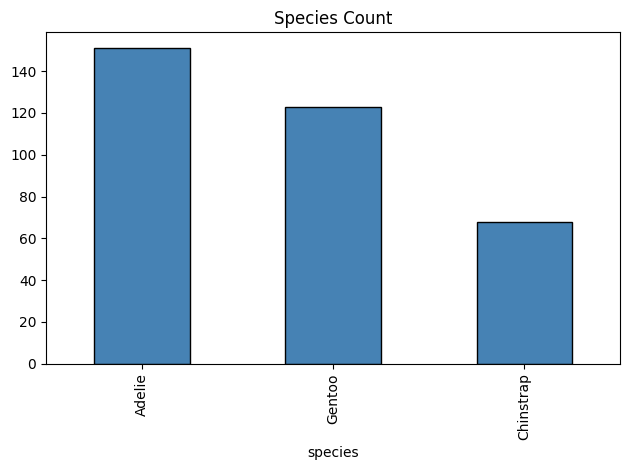

In [21]:
df['species'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Species Count')
plt.tight_layout()
plt.show()

### Findings from Species Count Plot

*   The bar plot visually confirms the distribution of species: Adelie is the most frequent, followed by Gentoo, and then Chinstrap.

This cell creates histograms for selected numerical features to visualize their distributions.

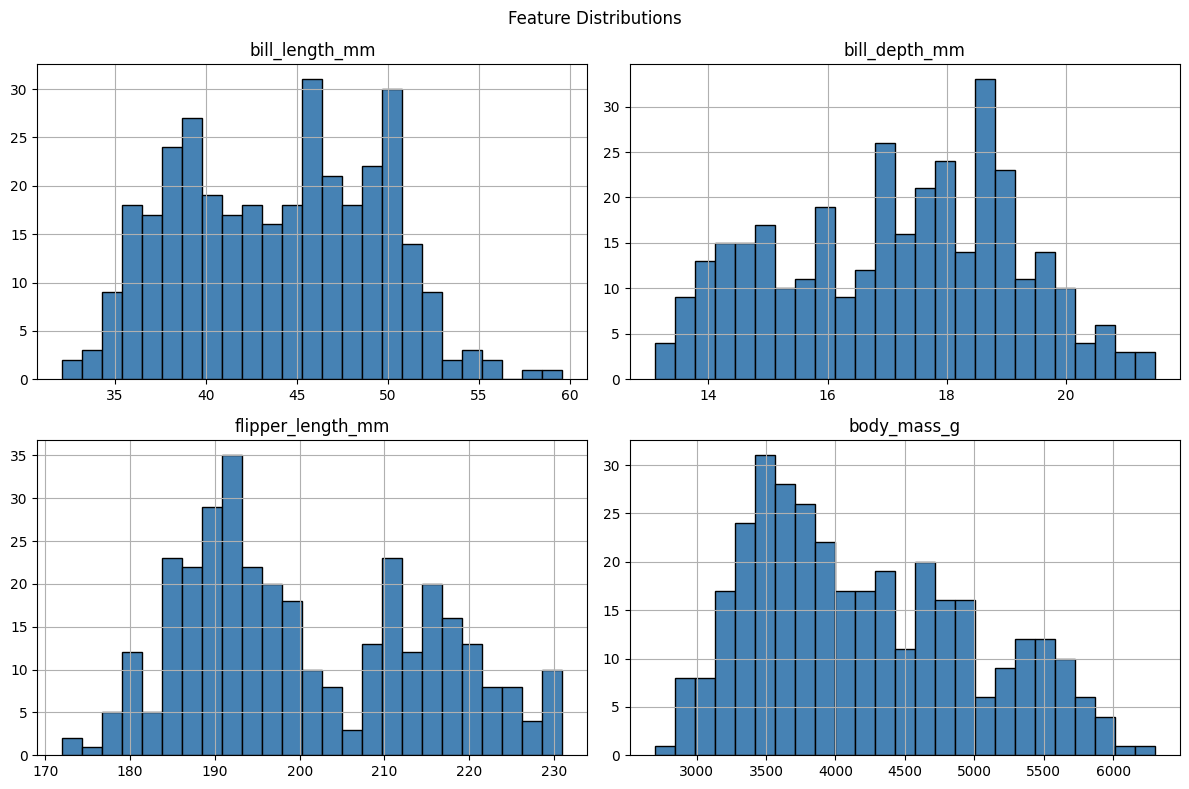

In [22]:
cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

df[cols].hist(bins=25, figsize=(12, 8), edgecolor='black', color='steelblue')
plt.suptitle('Feature Distributions')
plt.tight_layout()
plt.show()

### Findings from Feature Distributions

*   The histograms show the distribution of each numerical feature.
    *   `bill_length_mm` and `bill_depth_mm` appear to have multimodal distributions, suggesting differences between species.
    *   `flipper_length_mm` and `body_mass_g` also show similar multimodal tendencies, with a noticeable separation, likely due to distinct characteristics of the different penguin species.

This cell generates a heatmap to visualize the correlation matrix between the numerical features.

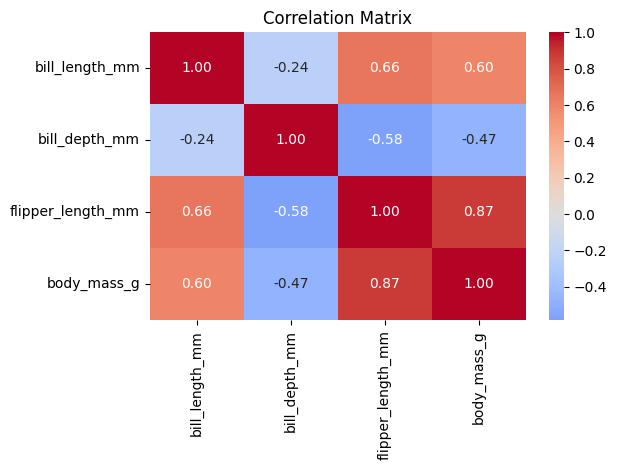

In [23]:
sns.heatmap(df[cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

### Findings from Correlation Matrix

*   The heatmap reveals correlations between numerical features:
    *   **Strong Positive Correlations:** `flipper_length_mm` is strongly positively correlated with `bill_length_mm` and `body_mass_g`. This indicates that larger penguins generally have longer flippers and bills. `bill_length_mm` and `body_mass_g` also show a strong positive correlation.
    *   **Moderate Correlations:** `bill_depth_mm` has a moderate negative correlation with `bill_length_mm` and a moderate positive correlation with `body_mass_g`.

This cell displays the DataFrame information again after data cleaning to show the updated non-null counts.

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 342 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            342 non-null    object 
 1   island             342 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                342 non-null    object 
dtypes: float64(4), object(3)
memory usage: 21.4+ KB


### Findings from `df.info()` (after cleaning)

*   The DataFrame now has 342 entries (2 rows were dropped due to missing `bill_length_mm`).
*   All columns show 342 non-null values, confirming that missing data has been successfully handled.
*   The data types remain consistent for the numerical and categorical features.

This cell initializes a `LabelEncoder` and converts the categorical 'species' column into numerical labels, storing them in a new 'species_enc' column.

In [26]:
le = LabelEncoder()
df['species_enc'] = le.fit_transform(df['species'])

This cell displays the newly created 'species_enc' column, showing the numerical representation of the species.

In [27]:
df['species_enc']

,species_enc
0,0
1,0
2,0
4,0
5,0
...,...
338,2
340,2
341,2
342,2


This cell performs one-hot encoding on the 'island' and 'sex' categorical columns, converting them into numerical features suitable for modeling. `drop_first=True` avoids multicollinearity.

In [28]:
# ── 3. Encode Categoricals ────────────────────────────────────────
df = pd.get_dummies(df, columns=['island', 'sex'], drop_first=True)

This cell defines the feature columns (`X`) and the target variable (`y`) for the machine learning model.

In [29]:
cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g',
        'island_Dream', 'island_Torgersen', 'sex_MALE']

X = df[cols]
y = df['species_enc']

This cell displays the first few rows of the feature DataFrame `X`.

In [32]:
X.head()


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,island_Dream,island_Torgersen,sex_MALE
0,39.1,18.7,181.0,3750.0,False,True,True
1,39.5,17.4,186.0,3800.0,False,True,False
2,40.3,18.0,195.0,3250.0,False,True,False
4,36.7,19.3,193.0,3450.0,False,True,False
5,39.3,20.6,190.0,3650.0,False,True,True


This cell displays the target variable `y`.

In [35]:
y

,species_enc
0,0
1,0
2,0
4,0
5,0
...,...
338,2
340,2
341,2
342,2


This cell splits the dataset into training and testing sets (80% train, 20% test) using `train_test_split`, ensuring stratification to maintain class proportions.

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

This cell initializes a `StandardScaler` to standardize the numerical features. It fits the scaler on the training data and then transforms both training and testing data.

In [37]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

This cell displays the shape (number of rows and columns) of the training feature set `X_train`.

In [39]:
X_train.shape

(273, 7)

This cell initializes a Logistic Regression model for multi-class classification, setting `multi_class='multinomial'` and a `random_state` for reproducibility.

In [40]:
model = LogisticRegression(multi_class='multinomial', random_state=42)

This cell trains the Logistic Regression model using the scaled training features (`X_train`) and target labels (`y_train`).

In [41]:
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(multi_class='multinomial', random_state=42)

This cell makes predictions on the test set using the trained Logistic Regression model and then prints the accuracy score and a detailed classification report.

In [44]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        30
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        25

    accuracy                           1.00        69
   macro avg       1.00      1.00      1.00        69
weighted avg       1.00      1.00      1.00        69



This cell generates and displays a confusion matrix for the Logistic Regression model, visualizing correct and incorrect predictions for each class.

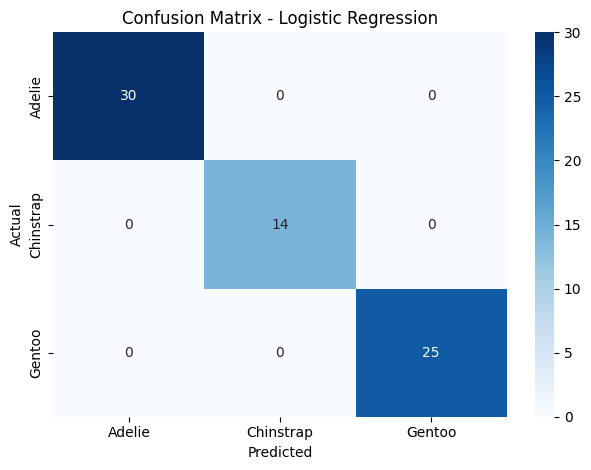

In [45]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

This cell uses `GridSearchCV` to find the optimal `n_neighbors` parameter for the KNN model by searching a range of values and performing cross-validation.

In [47]:
from sklearn.model_selection import GridSearchCV

params = {'n_neighbors': range(1, 21)}
grid = GridSearchCV(KNeighborsClassifier(), params, cv=5)
grid.fit(X_train, y_train)
print(grid.best_params_)

{'n_neighbors': 11}


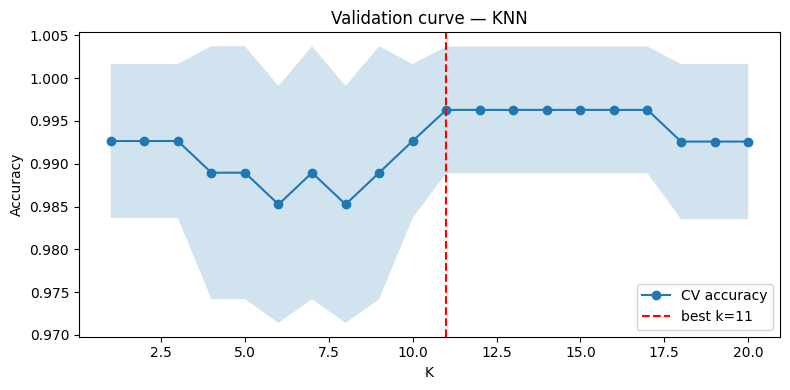

In [58]:
import matplotlib.pyplot as plt
import numpy as np

means  = grid.cv_results_['mean_test_score']
stds   = grid.cv_results_['std_test_score']
k_vals = range(1, 21)

plt.figure(figsize=(8, 4))
plt.plot(k_vals, means, marker='o', label='CV accuracy')
plt.fill_between(k_vals, means - stds, means + stds, alpha=0.2)
plt.axvline(grid.best_params_['n_neighbors'], color='red',
            linestyle='--', label=f"best k={grid.best_params_['n_neighbors']}")
plt.xlabel('K'); plt.ylabel('Accuracy')
plt.title('Validation curve — KNN')
plt.legend(); plt.tight_layout(); plt.show()

This cell initializes and trains a K-Nearest Neighbors (KNN) model using the best `n_neighbors` value found by `GridSearchCV`.

In [48]:
# ── 2. Train with Best K ──────────────────────────────────────────
model_knn = KNeighborsClassifier(n_neighbors=11)
model_knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=11)

This cell evaluates the trained KNN model by making predictions on the test set, printing the accuracy and classification report, and displaying its confusion matrix.

Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        30
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        25

    accuracy                           1.00        69
   macro avg       1.00      1.00      1.00        69
weighted avg       1.00      1.00      1.00        69



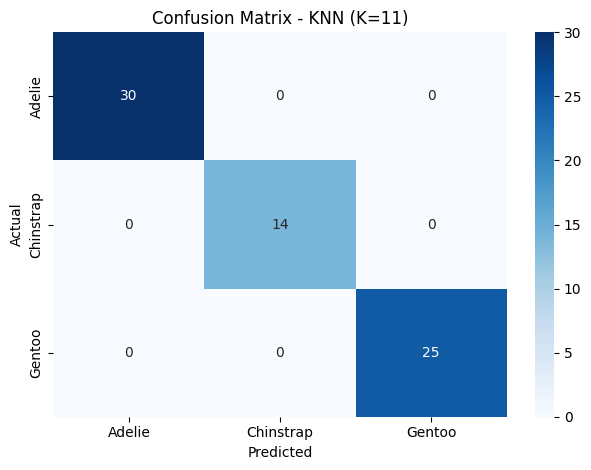

In [49]:
y_pred_knn = model_knn.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn, target_names=le.classes_))

cm_knn = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - KNN (K=11)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

This cell imports the Support Vector Classifier (`SVC`) from `sklearn.svm`, initializes it, and trains an SVM model on the scaled training data.

In [50]:
from sklearn.svm import SVC

# ── 1. Train ──────────────────────────────────────────────────────
model_svm = SVC(random_state=42)
model_svm.fit(X_train, y_train)


SVC(random_state=42)

This cell makes predictions using the trained SVM model on the test set and outputs the accuracy and classification report.

In [51]:
y_pred_svm = model_svm.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))

Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        30
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        25

    accuracy                           1.00        69
   macro avg       1.00      1.00      1.00        69
weighted avg       1.00      1.00      1.00        69



This cell visualizes the performance of the SVM model by generating and displaying its confusion matrix.

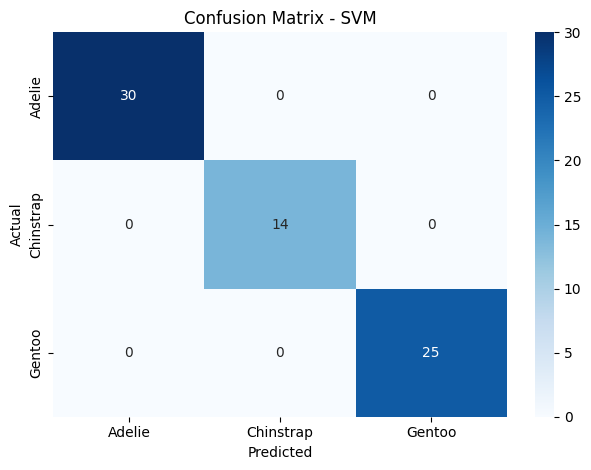

In [52]:
# ── 3. Confusion Matrix ───────────────────────────────────────────
cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - SVM')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [53]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# ── 1. Train ──────────────────────────────────────────────────────
model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [54]:
# ── 2. Evaluate ───────────────────────────────────────────────────
y_pred_dt = model_dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt, target_names=le.classes_))

Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        30
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        25

    accuracy                           1.00        69
   macro avg       1.00      1.00      1.00        69
weighted avg       1.00      1.00      1.00        69



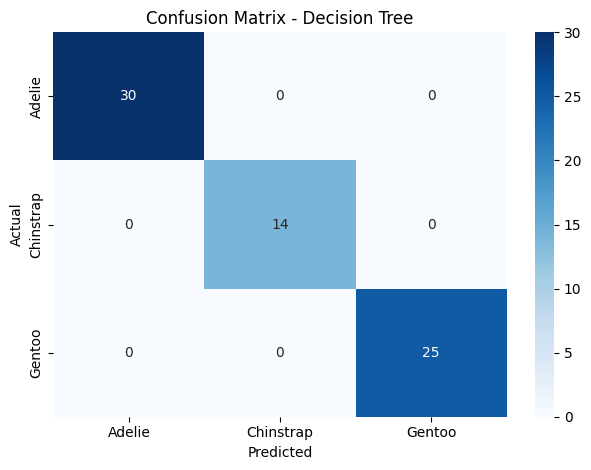

In [55]:
# ── 3. Confusion Matrix ───────────────────────────────────────────
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - Decision Tree')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

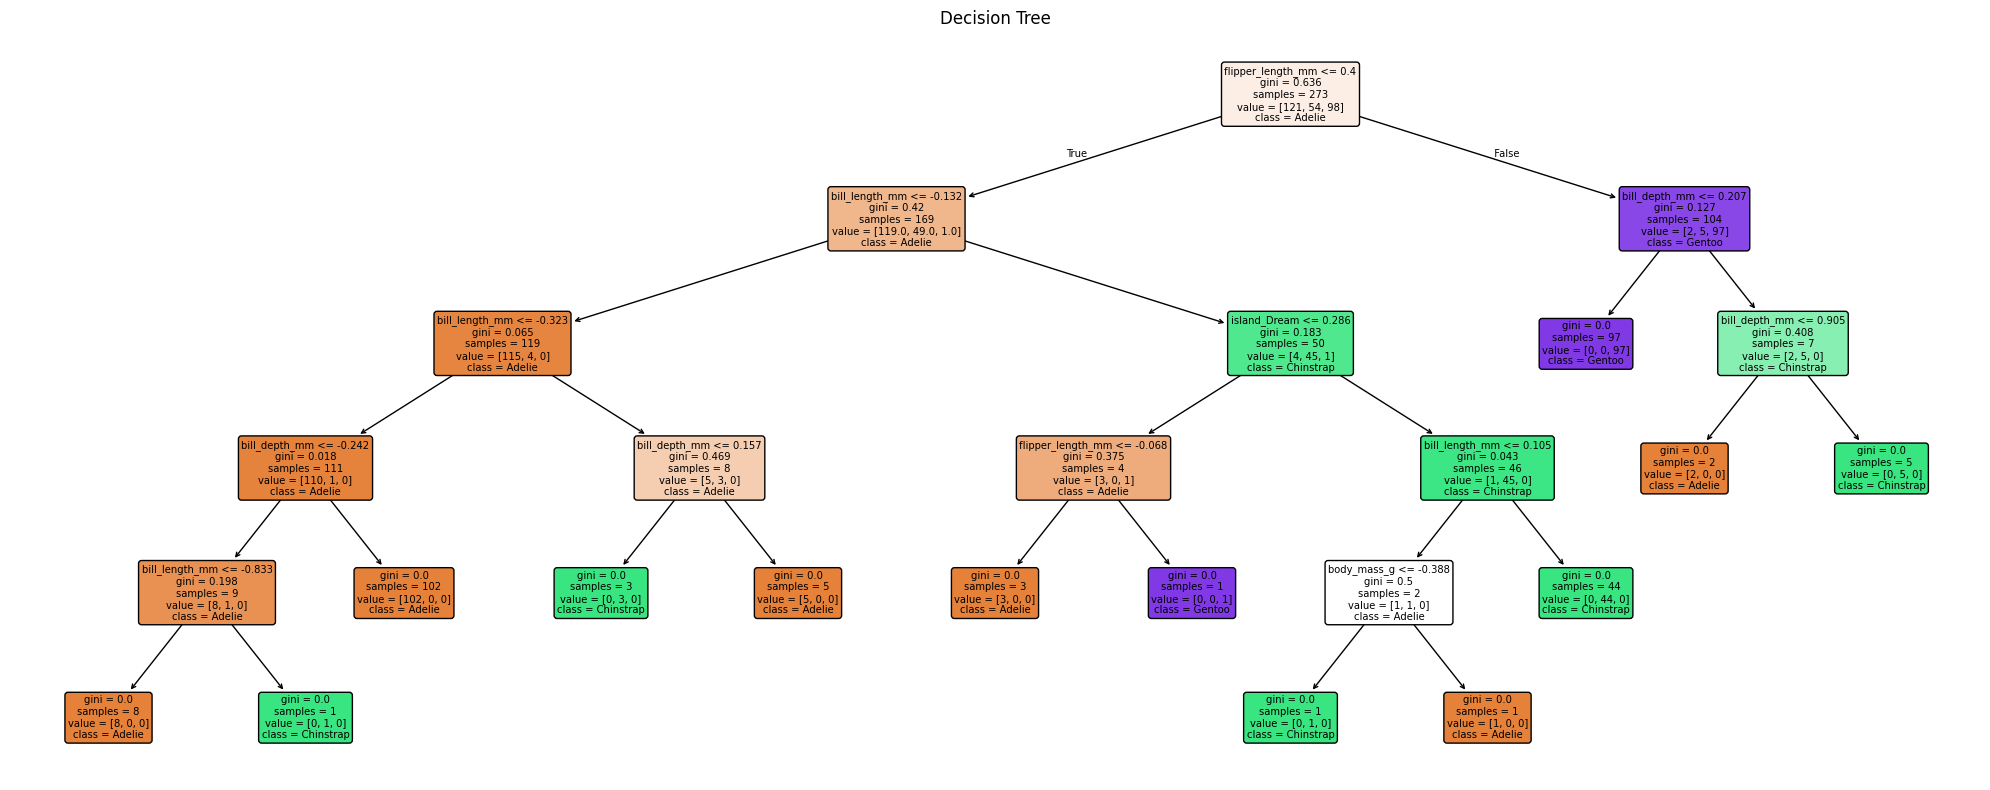

In [56]:
# ── 4. Visualize Tree ─────────────────────────────────────────────
plt.figure(figsize=(20, 8))
plot_tree(model_dt, feature_names=cols,
          class_names=le.classes_,
          filled=True, rounded=True)
plt.title('Decision Tree')
plt.tight_layout()
plt.show()


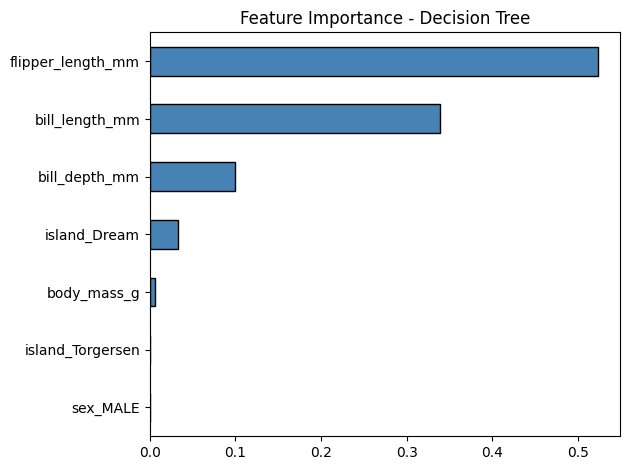

In [57]:
# ── 5. Feature Importance ─────────────────────────────────────────
importance = pd.Series(model_dt.feature_importances_, index=cols)
importance.sort_values().plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Feature Importance - Decision Tree')
plt.tight_layout()
plt.show()